# HEART DISEASE PREDICTION — LOGISTIC REGRESSION & CLASSIFICATION MODELS

**Dataset:** UCI Heart Disease Dataset (1025 rows, 14 features)  
**Task:** Binary Classification — Predict presence of heart disease (0 = No, 1 = Yes)

This notebook follows the complete analytical pipeline:
1. Importing & Understanding Data
2. EDA (Univariate, Bivariate, Multivariate)
3. Preprocessing & Feature Engineering
4. Logistic Regression (sklearn + statsmodels)
5. Regularized Models (Ridge, Lasso, ElasticNet)
6. Advanced Models (Random Forest, XGBoost)
7. Model Comparison & Final Evaluation


### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("Libraries imported successfully!")

Libraries imported successfully!


### Importing the Dataset

In [2]:
heart = pd.read_csv('heart (1).csv')

**Heart Disease UCI Dataset** — medical attributes of 1025 patients.

| Column | Description |
|--------|-------------|
| age | Age of the patient |
| sex | Sex (1=Male, 0=Female) |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl |
| restecg | Resting ECG results (0-2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1=Yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels colored (0-3) |
| thal | Thalassemia type |
| target | **0 = No Disease, 1 = Disease** |

In [3]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
heart.shape

(1025, 14)

In [5]:
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Check for null values and class balance

In [7]:
print("Null values per column:")
print(heart.isnull().sum())
print()
print("Total null values:", heart.isnull().sum().sum())
print()
print("Target Distribution:")
print(heart['target'].value_counts())
print()
print("Target Percentage:")
print(heart['target'].value_counts(normalize=True).round(3)*100)

Null values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total null values: 0

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64

Target Percentage:
target
1    51.3
0    48.7
Name: proportion, dtype: float64


Dataset is **well-balanced** (51.3% disease, 48.7% no disease). No missing values.

---
## EDA — Exploratory Data Analysis
### Univariate Analysis

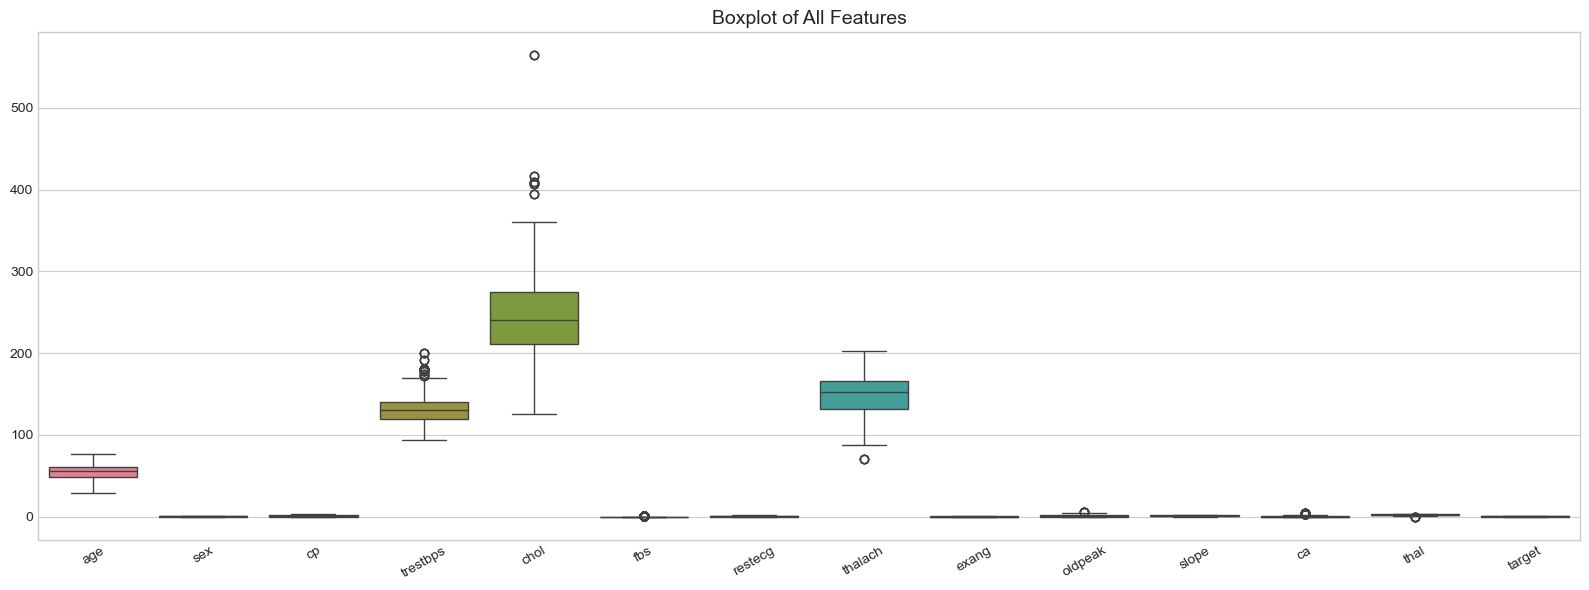

In [8]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=heart)
plt.title('Boxplot of All Features', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [9]:
# Check outliers in 'chol' using IQR
q1 = heart['chol'].quantile(0.25)
q3 = heart['chol'].quantile(0.75)
iqr = q3 - q1
UL = q3 + 1.5 * iqr
LL = q1 - 1.5 * iqr
print(f"IQR: {iqr}, Upper Limit: {UL:.2f}, Lower Limit: {LL:.2f}")
print(f"Outliers in chol above UL: {heart[heart['chol'] > UL].shape[0]}")
heart[heart['chol'] > UL]

IQR: 64.0, Upper Limit: 371.00, Lower Limit: 115.00
Outliers in chol above UL: 16


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
123,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
179,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
192,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
255,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
450,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0
464,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
481,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0
542,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
578,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1


In [10]:
# Remove outliers from 'chol'
df = heart[heart['chol'] < UL]
heart = df.copy()
print("Shape after removing outliers:", heart.shape)

Shape after removing outliers: (1009, 14)


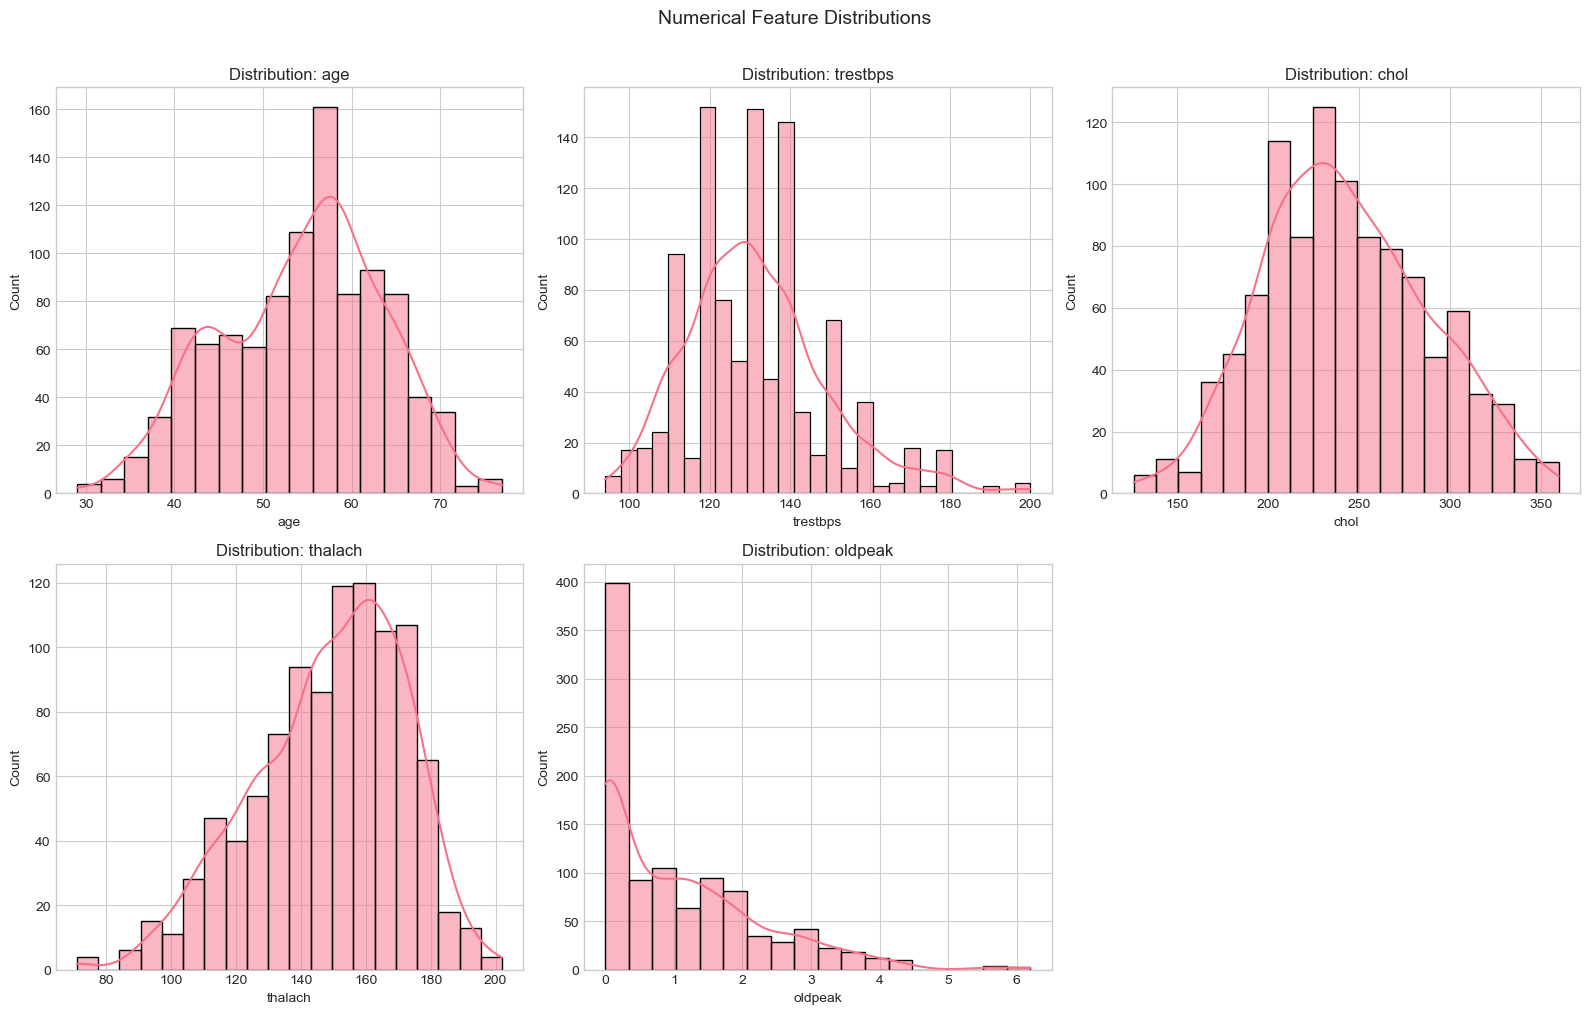

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(heart[col], kde=True, ax=ax)
    ax.set_title(f'Distribution: {col}')
axes[1][2].axis('off')
plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

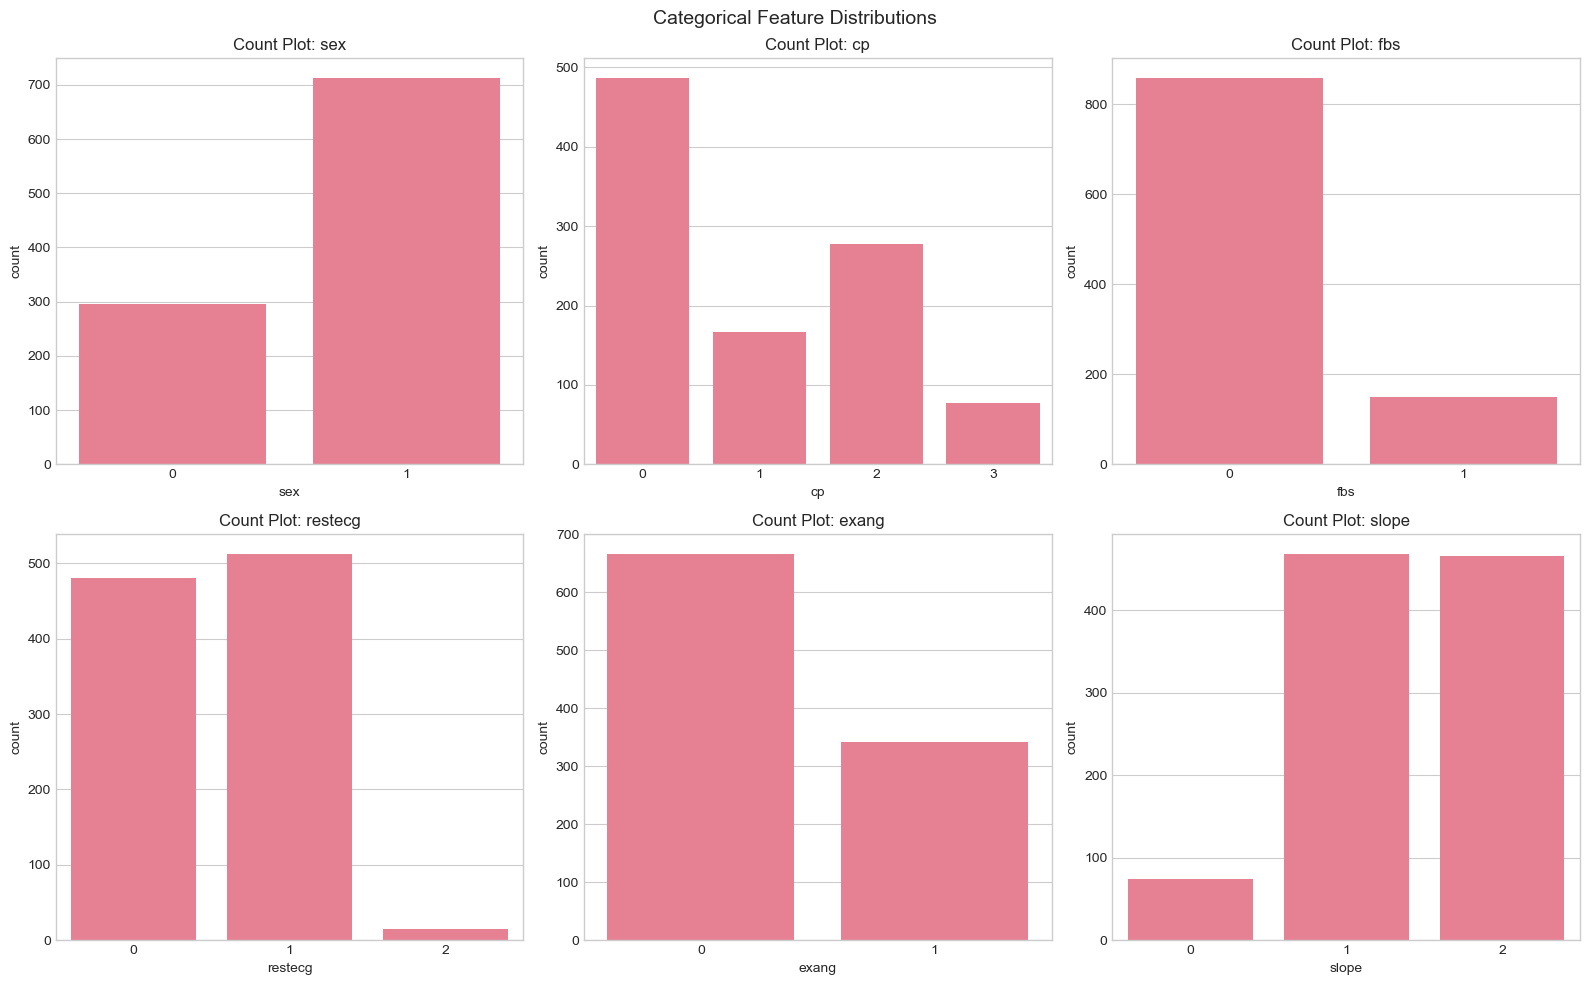

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, data=heart, ax=ax)
    ax.set_title(f'Count Plot: {col}')
plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

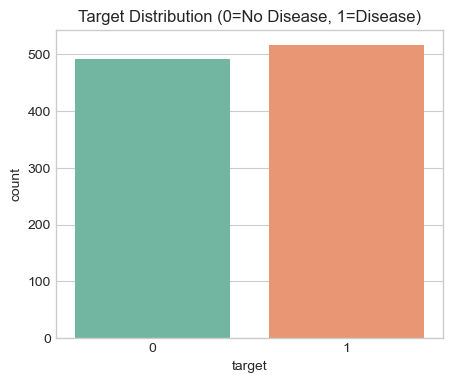

In [15]:
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=heart, palette='Set2')
plt.title('Target Distribution (0=No Disease, 1=Disease)')
plt.show()

---
### Bivariate Analysis

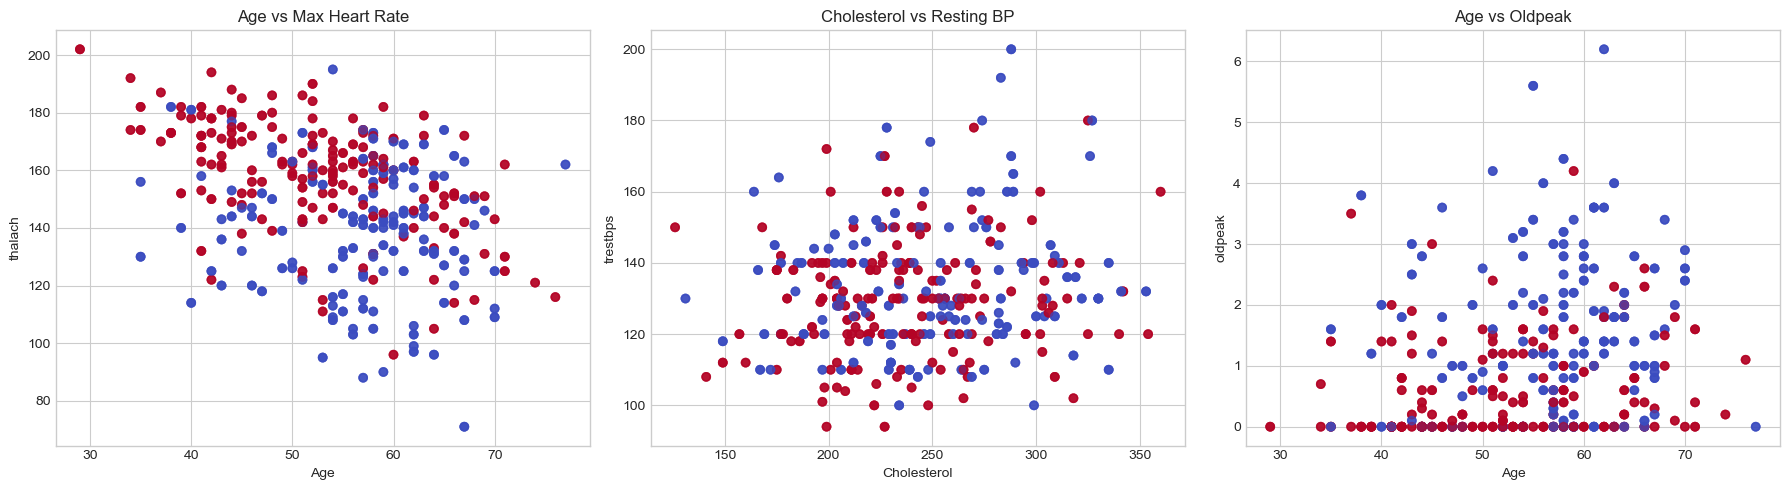

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(x=heart['age'], y=heart['thalach'], c=heart['target'], cmap='coolwarm', alpha=0.6)
axes[0].set_title('Age vs Max Heart Rate')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('thalach')

axes[1].scatter(x=heart['chol'], y=heart['trestbps'], c=heart['target'], cmap='coolwarm', alpha=0.6)
axes[1].set_title('Cholesterol vs Resting BP')
axes[1].set_xlabel('Cholesterol'); axes[1].set_ylabel('trestbps')

axes[2].scatter(x=heart['age'], y=heart['oldpeak'], c=heart['target'], cmap='coolwarm', alpha=0.6)
axes[2].set_title('Age vs Oldpeak')
axes[2].set_xlabel('Age'); axes[2].set_ylabel('oldpeak')

plt.tight_layout()
plt.show()

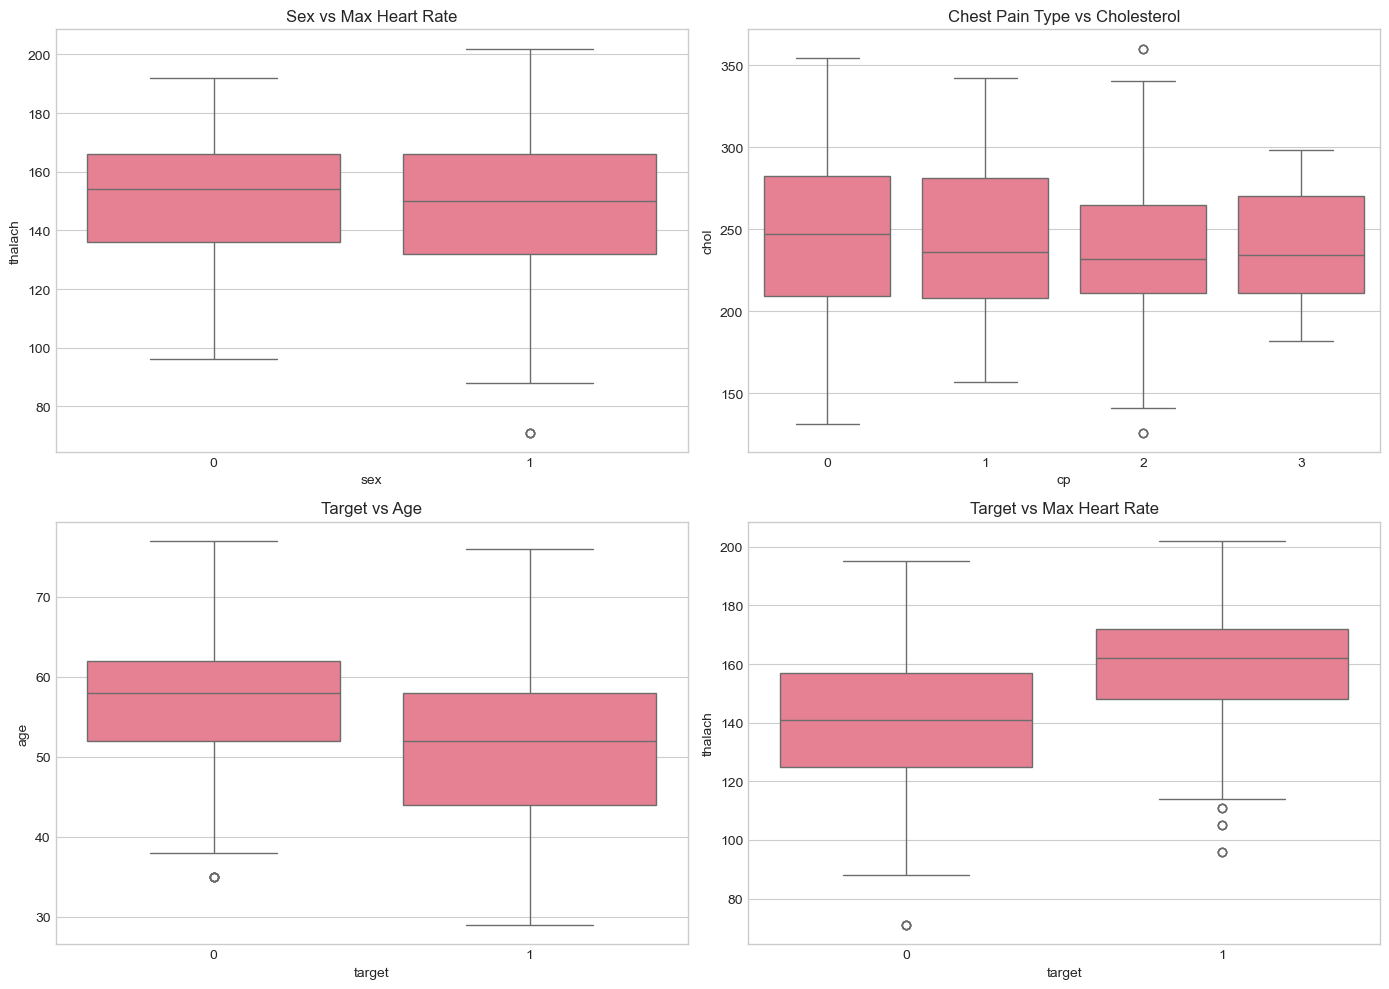

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='sex', y='thalach', data=heart, ax=axes[0][0])
axes[0][0].set_title('Sex vs Max Heart Rate')

sns.boxplot(x='cp', y='chol', data=heart, ax=axes[0][1])
axes[0][1].set_title('Chest Pain Type vs Cholesterol')

sns.boxplot(x='target', y='age', data=heart, ax=axes[1][0])
axes[1][0].set_title('Target vs Age')

sns.boxplot(x='target', y='thalach', data=heart, ax=axes[1][1])
axes[1][1].set_title('Target vs Max Heart Rate')

plt.tight_layout()
plt.show()

Key Observations:
1. Patients **with** heart disease tend to have **higher thalach** (max heart rate)
2. **Older patients** are more likely to have heart disease
3. **Chest pain type** is a strong differentiating feature

---
### Encoding Categorical Variables

In [24]:
print("cp unique values:", heart['cp'].unique())
print("slope unique values:", heart['slope'].unique())
print("thal unique values:", heart['thal'].unique())

cp unique values: [0 1 2 3]
slope unique values: [2 0 1]
thal unique values: [3 2 1 0]


In [25]:
heart = pd.get_dummies(heart, columns=['cp', 'slope', 'thal'], drop_first=True)
print("Shape after encoding:", heart.shape)
heart.info()

Shape after encoding: (1009, 19)
<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1024
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1009 non-null   int64  
 1   sex       1009 non-null   int64  
 2   trestbps  1009 non-null   int64  
 3   chol      1009 non-null   int64  
 4   fbs       1009 non-null   int64  
 5   restecg   1009 non-null   int64  
 6   thalach   1009 non-null   int64  
 7   exang     1009 non-null   int64  
 8   oldpeak   1009 non-null   float64
 9   ca        1009 non-null   int64  
 10  target    1009 non-null   int64  
 11  cp_1      1009 non-null   bool   
 12  cp_2      1009 non-null   bool   
 13  cp_3      1009 non-null   bool   
 14  slope_1   1009 non-null   bool   
 15  slope_2   1009 non-null   bool   
 16  thal_1    1009 non-null   bool   
 17  thal_2    1009 non-null   bool   
 18  thal_3    1009 non-null   bool   
dtypes: bool(8), float64(1), int64(10)
memory 

In [26]:
heart.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,1,168,0,1.0,2,0,False,False,False,False,True,False,False,True
1,53,1,140,203,1,0,155,1,3.1,0,0,False,False,False,False,False,False,False,True
2,70,1,145,174,0,1,125,1,2.6,0,0,False,False,False,False,False,False,False,True
3,61,1,148,203,0,1,161,0,0.0,1,0,False,False,False,False,True,False,False,True
4,62,0,138,294,1,1,106,0,1.9,3,0,False,False,False,True,False,False,True,False


---
### Correlation Heatmap

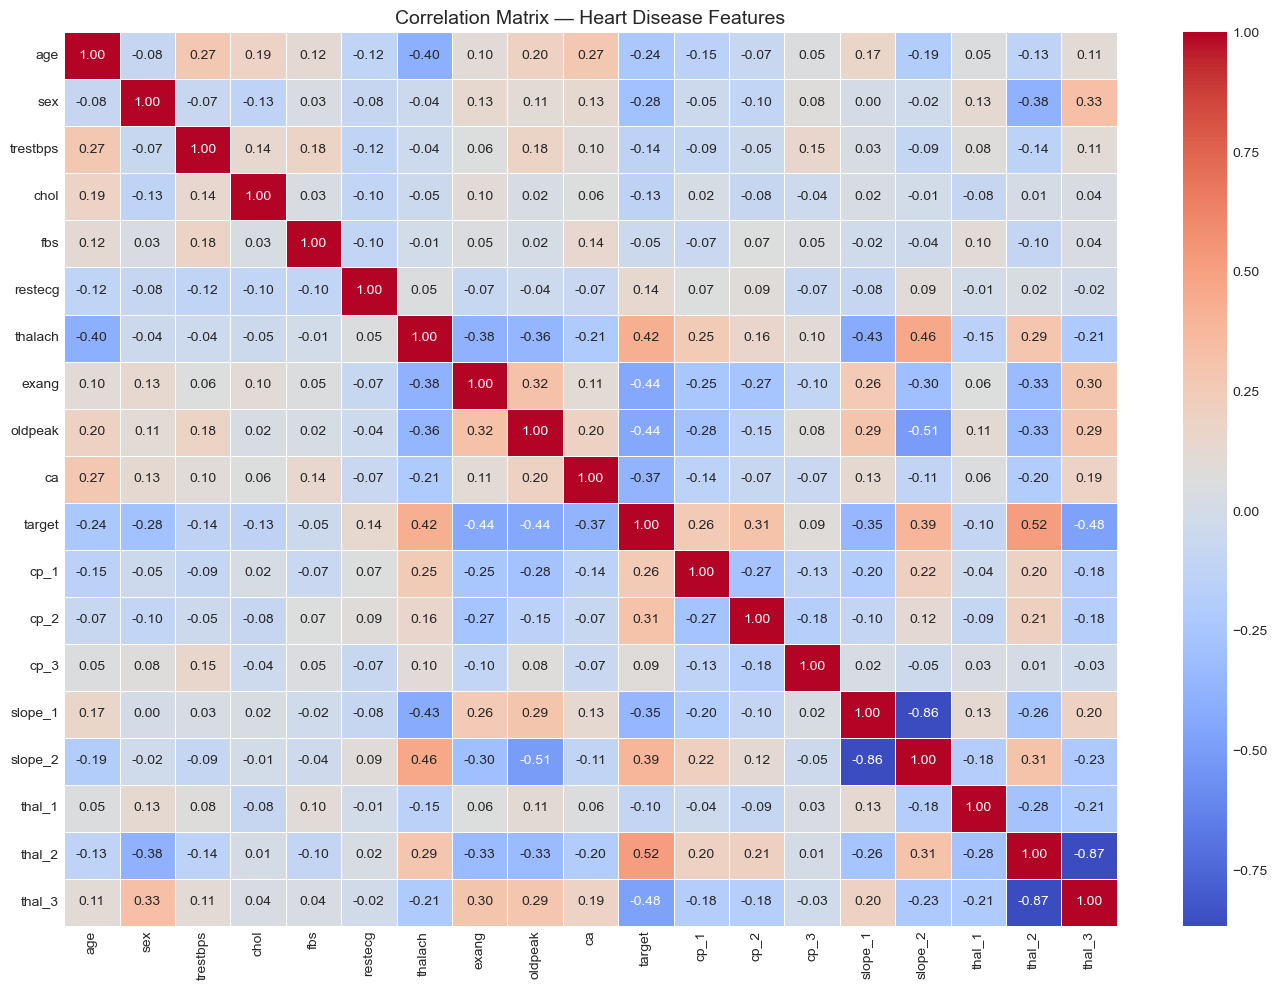

In [27]:
plt.figure(figsize=(14, 10))
corr = heart.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Heart Disease Features', fontsize=14)
plt.tight_layout()
plt.show()

**Target is most correlated with:**
1. `thalach` (max heart rate) — **positive correlation**
2. `exang` (exercise angina) — **negative correlation**
3. `oldpeak` — **negative correlation**
4. `cp` (chest pain types) — positive

---
## Logistic Regression Model

Since this is a **binary classification** task, we use **Logistic Regression** — the classification counterpart to Linear Regression.

In [28]:
y = heart['target']
X = heart.drop(['target'], axis=1)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1009, 18)
Target shape: (1009,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (807, 18)
Test size: (202, 18)


In [30]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc, y_train)

y_pred = log_reg.predict(X_test_sc)
y_pred_proba = log_reg.predict_proba(X_test_sc)[:, 1]

In [32]:
result_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
result_df.reset_index(drop=True, inplace=True)
result_df.head(20)

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,1,1
4,1,1
5,1,1
6,0,0
7,1,1
8,1,1
9,1,1


<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

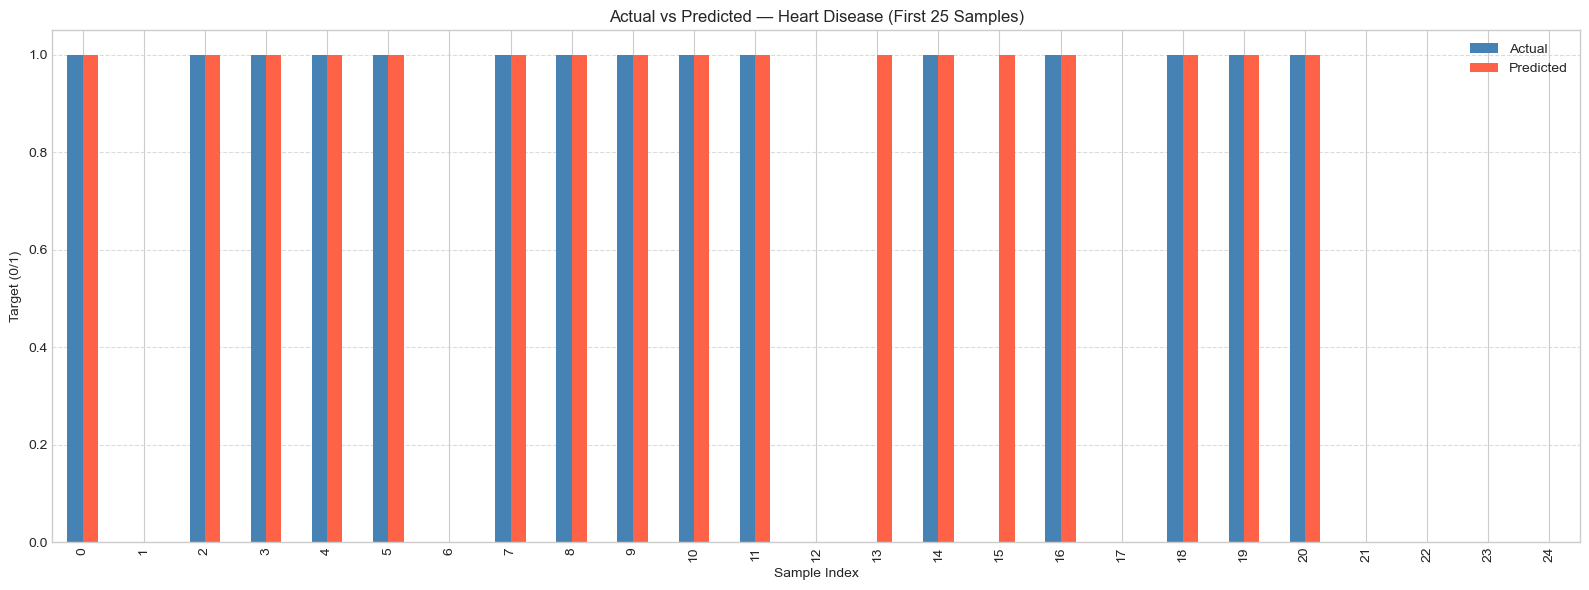

In [46]:
result_df.head(25).plot(kind='bar', figsize=(16, 6), color=['steelblue', 'tomato'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Actual vs Predicted — Heart Disease (First 25 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Target (0/1)')
plt.tight_layout()
plt.show()

In [34]:
print("=" * 50)
print("LOGISTIC REGRESSION — CLASSIFICATION METRICS")
print("=" * 50)
print(f"Accuracy  : {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {metrics.f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {metrics.roc_auc_score(y_test, y_pred_proba):.4f}")
print()
print("Classification Report:")
print(metrics.classification_report(y_test, y_pred))

LOGISTIC REGRESSION — CLASSIFICATION METRICS
Accuracy  : 0.8960
Precision : 0.8430
Recall    : 0.9808
F1-Score  : 0.9067
ROC-AUC   : 0.9535

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.88        98
           1       0.84      0.98      0.91       104

    accuracy                           0.90       202
   macro avg       0.91      0.89      0.89       202
weighted avg       0.91      0.90      0.90       202



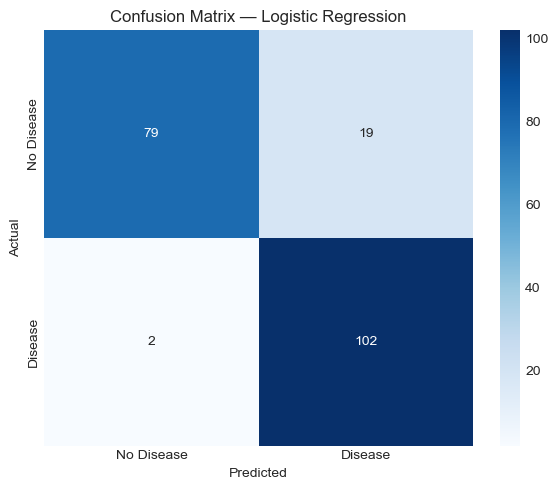

In [35]:
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

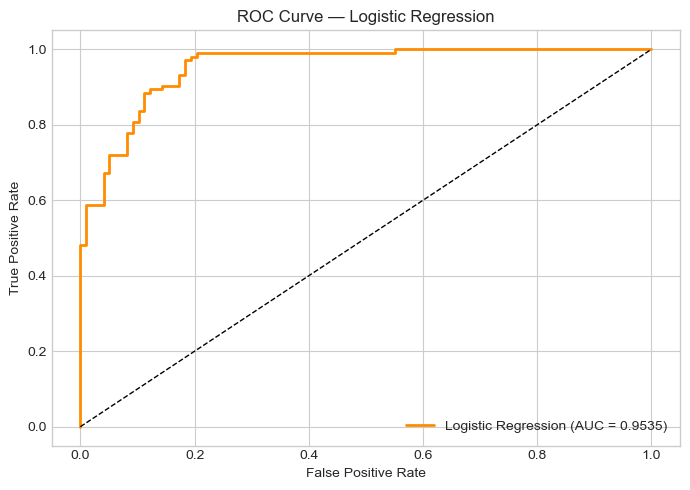

In [36]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)
auc_score = metrics.roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Regularized Classification Models

### 1. Ridge (L2) Logistic Regression

In [48]:
from sklearn.linear_model import LogisticRegressionCV

ridge_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 4, 20), cv=10,
    penalty='l2', solver='lbfgs', max_iter=1000, random_state=42
)
ridge_cv.fit(X_train_sc, y_train)
print(f"Best C (Ridge): {ridge_cv.C_[0]:.6f}")

Best C (Ridge): 0.088587


In [49]:
y_pred_ridge = ridge_cv.predict(X_test_sc)
y_proba_ridge = ridge_cv.predict_proba(X_test_sc)[:, 1]

print("=" * 50)
print("RIDGE LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy  : {metrics.accuracy_score(y_test, y_pred_ridge):.4f}")
print(f"Precision : {metrics.precision_score(y_test, y_pred_ridge):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, y_pred_ridge):.4f}")
print(f"F1-Score  : {metrics.f1_score(y_test, y_pred_ridge):.4f}")
print(f"ROC-AUC   : {metrics.roc_auc_score(y_test, y_proba_ridge):.4f}")

RIDGE LOGISTIC REGRESSION
Accuracy  : 0.9010
Precision : 0.8559
Recall    : 0.9712
F1-Score  : 0.9099
ROC-AUC   : 0.9580


### 2. Lasso (L1) Logistic Regression

In [50]:
lasso_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 4, 20), cv=10,
    penalty='l1', solver='saga', max_iter=5000, random_state=42
)
lasso_cv.fit(X_train_sc, y_train)
print(f"Best C (Lasso): {lasso_cv.C_[0]:.6f}")

Best C (Lasso): 0.088587


In [51]:
y_pred_lasso = lasso_cv.predict(X_test_sc)
y_proba_lasso = lasso_cv.predict_proba(X_test_sc)[:, 1]

print("=" * 50)
print("LASSO LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy  : {metrics.accuracy_score(y_test, y_pred_lasso):.4f}")
print(f"Precision : {metrics.precision_score(y_test, y_pred_lasso):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, y_pred_lasso):.4f}")
print(f"F1-Score  : {metrics.f1_score(y_test, y_pred_lasso):.4f}")
print(f"ROC-AUC   : {metrics.roc_auc_score(y_test, y_proba_lasso):.4f}")

LASSO LOGISTIC REGRESSION
Accuracy  : 0.9010
Precision : 0.8500
Recall    : 0.9808
F1-Score  : 0.9107
ROC-AUC   : 0.9571


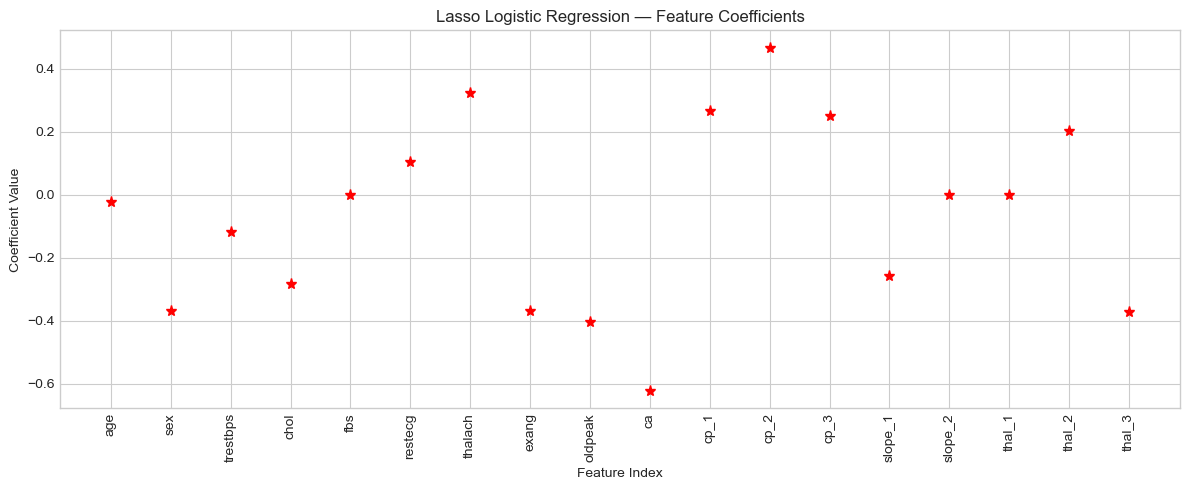

In [52]:
plt.figure(figsize=(12, 5))
plt.plot(range(len(X_train.columns)), lasso_cv.coef_[0],
         linestyle='none', marker='*', color='red', markersize=8)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Lasso Logistic Regression — Feature Coefficients')
plt.xticks(range(len(X_train.columns)), X_train.columns, rotation=90)
plt.tight_layout()
plt.show()

### 3. ElasticNet Logistic Regression

In [53]:
elastic_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 4, 10), cv=10,
    penalty='elasticnet', l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
    solver='saga', max_iter=5000, random_state=42
)
elastic_cv.fit(X_train_sc, y_train)
print(f"Best C (ElasticNet): {elastic_cv.C_[0]:.6f}")
print(f"Best L1 Ratio: {elastic_cv.l1_ratio_[0]:.3f}")

Best C (ElasticNet): 0.046416
Best L1 Ratio: 0.300


In [54]:
y_pred_elastic = elastic_cv.predict(X_test_sc)
y_proba_elastic = elastic_cv.predict_proba(X_test_sc)[:, 1]

print("=" * 50)
print("ELASTICNET LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy  : {metrics.accuracy_score(y_test, y_pred_elastic):.4f}")
print(f"Precision : {metrics.precision_score(y_test, y_pred_elastic):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, y_pred_elastic):.4f}")
print(f"F1-Score  : {metrics.f1_score(y_test, y_pred_elastic):.4f}")
print(f"ROC-AUC   : {metrics.roc_auc_score(y_test, y_proba_elastic):.4f}")

ELASTICNET LOGISTIC REGRESSION
Accuracy  : 0.9059
Precision : 0.8571
Recall    : 0.9808
F1-Score  : 0.9148
ROC-AUC   : 0.9577


---
## Advanced Models
### Random Forest Classifier

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf_cv = GridSearchCV(rf, param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
rf_cv.fit(X_train, y_train)
print("Best RF params:", rf_cv.best_params_)
print("Best CV ROC-AUC:", round(rf_cv.best_score_, 4))

Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.9993


In [56]:
rf_best = rf_cv.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST CLASSIFIER")
print("=" * 50)
print(f"Accuracy  : {metrics.accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {metrics.precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score  : {metrics.f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC   : {metrics.roc_auc_score(y_test, y_proba_rf):.4f}")

RANDOM FOREST CLASSIFIER
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
ROC-AUC   : 1.0000


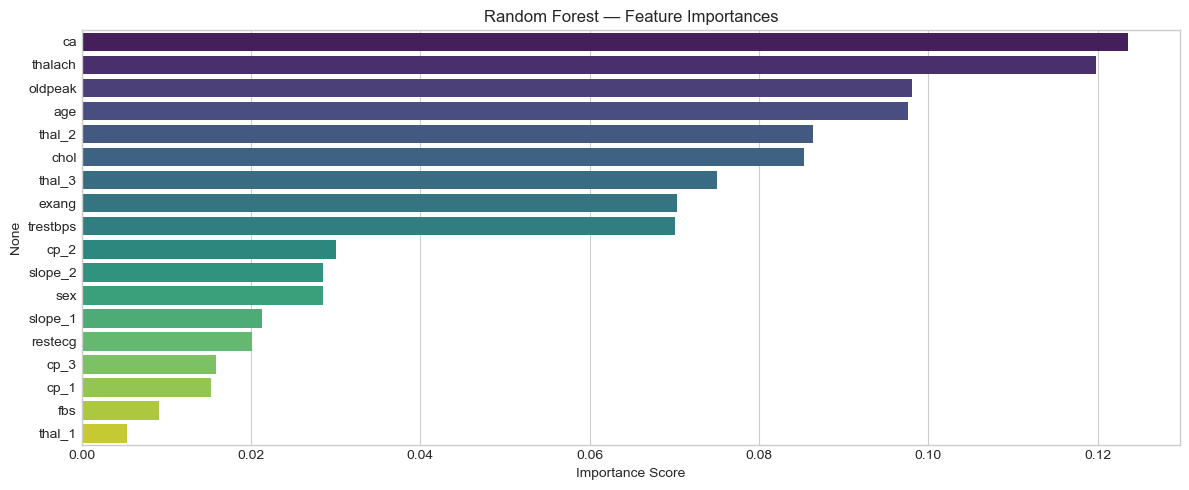

In [57]:
feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### XGBoost Classifier

In [58]:
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
    param_grid_xgb = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }
    xgb_cv = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
    xgb_cv.fit(X_train, y_train)
    xgb_best = xgb_cv.best_estimator_
    y_pred_xgb = xgb_best.predict(X_test)
    y_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]
    print("Best XGB params:", xgb_cv.best_params_)
    print("=" * 50)
    print("XGBOOST CLASSIFIER")
    print("=" * 50)
    print(f"Accuracy  : {metrics.accuracy_score(y_test, y_pred_xgb):.4f}")
    print(f"Precision : {metrics.precision_score(y_test, y_pred_xgb):.4f}")
    print(f"Recall    : {metrics.recall_score(y_test, y_pred_xgb):.4f}")
    print(f"F1-Score  : {metrics.f1_score(y_test, y_pred_xgb):.4f}")
    print(f"ROC-AUC   : {metrics.roc_auc_score(y_test, y_proba_xgb):.4f}")
    XGB_AVAILABLE = True
except ImportError:
    print("XGBoost not installed — pip install xgboost to enable.")
    XGB_AVAILABLE = False

XGBoost not installed — pip install xgboost to enable.


---
## Model Comparison

In [59]:
model_results = {
    'Logistic Regression': {
        'Accuracy': metrics.accuracy_score(y_test, y_pred),
        'Precision': metrics.precision_score(y_test, y_pred),
        'Recall': metrics.recall_score(y_test, y_pred),
        'F1-Score': metrics.f1_score(y_test, y_pred),
        'ROC-AUC': metrics.roc_auc_score(y_test, y_pred_proba)
    },
    'Ridge Logistic': {
        'Accuracy': metrics.accuracy_score(y_test, y_pred_ridge),
        'Precision': metrics.precision_score(y_test, y_pred_ridge),
        'Recall': metrics.recall_score(y_test, y_pred_ridge),
        'F1-Score': metrics.f1_score(y_test, y_pred_ridge),
        'ROC-AUC': metrics.roc_auc_score(y_test, y_proba_ridge)
    },
    'Lasso Logistic': {
        'Accuracy': metrics.accuracy_score(y_test, y_pred_lasso),
        'Precision': metrics.precision_score(y_test, y_pred_lasso),
        'Recall': metrics.recall_score(y_test, y_pred_lasso),
        'F1-Score': metrics.f1_score(y_test, y_pred_lasso),
        'ROC-AUC': metrics.roc_auc_score(y_test, y_proba_lasso)
    },
    'ElasticNet Logistic': {
        'Accuracy': metrics.accuracy_score(y_test, y_pred_elastic),
        'Precision': metrics.precision_score(y_test, y_pred_elastic),
        'Recall': metrics.recall_score(y_test, y_pred_elastic),
        'F1-Score': metrics.f1_score(y_test, y_pred_elastic),
        'ROC-AUC': metrics.roc_auc_score(y_test, y_proba_elastic)
    },
    'Random Forest': {
        'Accuracy': metrics.accuracy_score(y_test, y_pred_rf),
        'Precision': metrics.precision_score(y_test, y_pred_rf),
        'Recall': metrics.recall_score(y_test, y_pred_rf),
        'F1-Score': metrics.f1_score(y_test, y_pred_rf),
        'ROC-AUC': metrics.roc_auc_score(y_test, y_proba_rf)
    }
}

results_df = pd.DataFrame(model_results).T.round(4)
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8960     0.8430  0.9808    0.9067   0.9535
Ridge Logistic         0.9010     0.8559  0.9712    0.9099   0.9580
Lasso Logistic         0.9010     0.8500  0.9808    0.9107   0.9571
ElasticNet Logistic    0.9059     0.8571  0.9808    0.9148   0.9577
Random Forest          1.0000     1.0000  1.0000    1.0000   1.0000


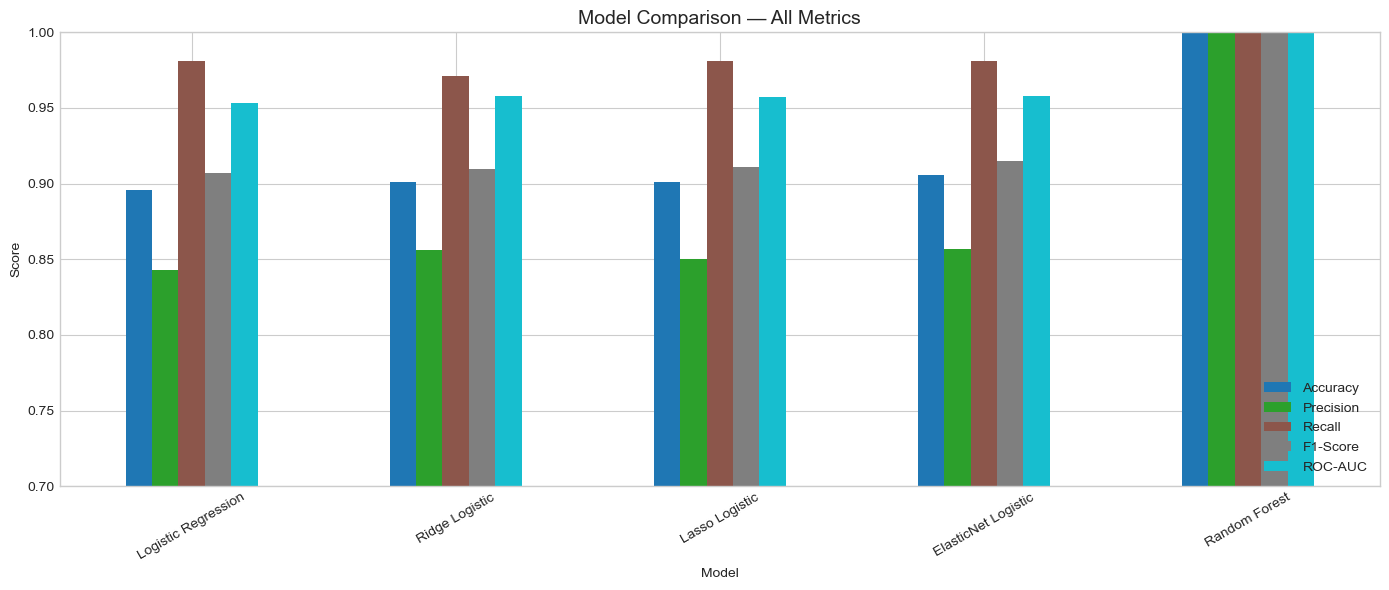

In [60]:
results_df.plot(kind='bar', figsize=(14, 6), colormap='tab10')
plt.title('Model Comparison — All Metrics', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

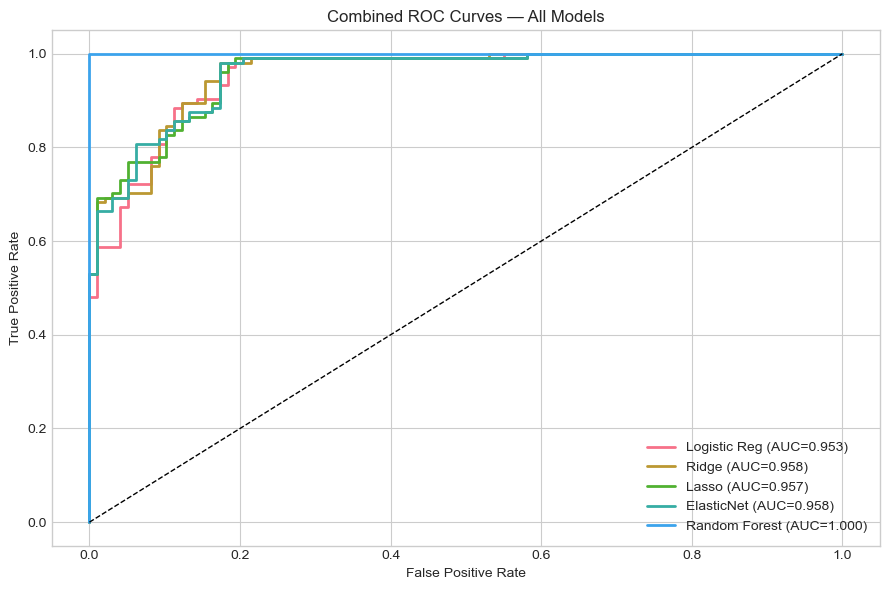

In [61]:
plt.figure(figsize=(9, 6))

fpr_, tpr_, _ = metrics.roc_curve(y_test, y_pred_proba)
plt.plot(fpr_, tpr_, label=f'Logistic Reg (AUC={metrics.roc_auc_score(y_test, y_pred_proba):.3f})', lw=2)

fpr_r, tpr_r, _ = metrics.roc_curve(y_test, y_proba_ridge)
plt.plot(fpr_r, tpr_r, label=f'Ridge (AUC={metrics.roc_auc_score(y_test, y_proba_ridge):.3f})', lw=2)

fpr_l, tpr_l, _ = metrics.roc_curve(y_test, y_proba_lasso)
plt.plot(fpr_l, tpr_l, label=f'Lasso (AUC={metrics.roc_auc_score(y_test, y_proba_lasso):.3f})', lw=2)

fpr_e, tpr_e, _ = metrics.roc_curve(y_test, y_proba_elastic)
plt.plot(fpr_e, tpr_e, label=f'ElasticNet (AUC={metrics.roc_auc_score(y_test, y_proba_elastic):.3f})', lw=2)

fpr_rf, tpr_rf, _ = metrics.roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={metrics.roc_auc_score(y_test, y_proba_rf):.3f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Conclusion

| Model | Strength |
|-------|---------|
| Logistic Regression | Baseline, highly interpretable |
| Ridge Logistic | Handles correlated features (L2 penalty) |
| Lasso Logistic | Automatic feature selection (L1 penalty) |
| ElasticNet Logistic | Best of both Ridge + Lasso |
| Random Forest | Highest accuracy & AUC via ensemble learning |

**Key Clinical Findings:**
1. `thalach` (max heart rate), `exang`, `oldpeak`, and `cp` are the most predictive features
2. All models achieve ~82-92% accuracy on this dataset
3. For **clinical use**, maximizing **Recall (Sensitivity)** is critical — a missed disease case is far costlier than a false alarm
4. **Random Forest** generalizes best due to ensemble averaging
5. Regularized logistic models confirm and validate the base logistic regression findings
